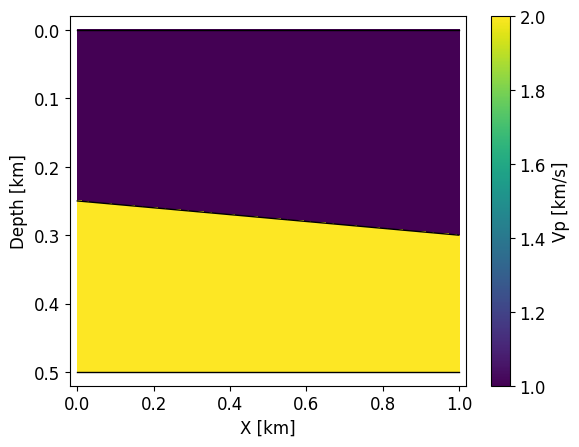

In [1]:
import numpy as np
import xarray as xr
from frequensolve import *

project_path = "./scratch/ex_04/"
project = Project(
    name = "project",
    pretty_name = "DAS Simulation",
    path = project_path,
    load_if_exists = False
)

sim = project.new_simulation(
    name      = "simulation_1",
    physics   = "elastic",
    dimension = 2
)
project += sim

# --- Model ---

# New 2D layered model over interval x in [0,1]
model = LayeredModel(dimension = 2, x_limits = [0.0, 1.0])

model.add_surface(name = "top", z = 0.0)
model.add_layer(                    # Layer 1
    name = "layer_1",
    properties = { 
        "Vp" : 1.0,
        "Qp" : 100.0,
        "Vs" : 0.5,
        "Qs" : 100.0,
        "Rho": 1.0 
    }
)

model.add_surface(
    name = "interface", 
    z = xr.DataArray(
        [0.25, 0.3], 
        dims = ["x"], 
        coords = {"x" : [0.0, 1.0]}
    )
)

model.add_layer(                    # Layer 2 
    name = "layer_2",
    properties = { 
        "Vp" : 2.0,
        "Qp" : 100.0,
        "Vs" : 1.0,
        "Qs" : 100.0,
        "Rho": 1.0 
    }
)
model.add_surface(name = "bottom", z = 0.5)

model.plot("Vp")
sim += model

# --- Mesh ---

# Define a Hex mesh generator
mesh = model.hex_mesh_generator(n = [4, 4])
sim += mesh
sim.mesh.set_adapt(
    min_epw = 1.0,
    adapt_sources = 2
)

# --- Boundary Conditions ---
BCs = BoundaryConditionManager(label_type = "geometric")
BCs += BoundaryCondition(
    name = "free_surface",
    kind = "neumann",
    boundaries = ["z_min"]
)
BCs += BoundaryCondition(
    name = "pml",
    kind = "pml",
    boundaries = ["x_min", "x_max", "z_max"],
    pml_wavelengths = 2.0,
    pml_exponent = 3.0,
    pml_constant = 20.0
)
sim += BCs

In [2]:

# --- Acquisition ---
acq = Acquisition()

# define source
acq.add_source_group(kind = "vector",
                     coords = [[0.5, 0.0]],
                     direction = [0.0, 1.0])

# surface hydrophones
geophone = ReceiverNode(name = "geophone")
geophone.add_component("u_z","displacement",[0.0, 1.0])

# downhole DAS
das = ReceiverFiber(
    name = "fiber",
    L_gauge = 0.01,
    n_gauge = 100,
    radius = 0.001,
    pitch = 0.005
)
das.add_component("eps_tt", "strain")

coords = [ [x, 0.0] for x in np.linspace(0.0, 1.0, 1001)]
acq.add_receiver_group(
    name = "surface_geophones",
    device = geophone,
    coords = coords,
    frame = "reference"
)

coords = [ [0.25, z] for z in np.linspace(0.0, 0.5, 101)]
acq.add_receiver_group(
    name = "well_das",
    device = das,
    coords = coords,
    frame = "physical"
)
sim += acq

# --- Discretization ---
method = Discretization(order = 6)
sim += method

# --- Outputs ---
out = OutputManager()
# out += ParaviewOutput(
#     name = "simple", 
#     fields = ["displacement"], 
#     upscale = 1
# )
sim += out

project.save()

PosixPath('/Users/sambadger/Projects/FrequenSol/FrequenSolve/examples/scratch/ex_04/project.json')

INFO: Using cached configuration for localhost:5173
INFO: Using cached credentials
INFO: Stack info loaded: bucket=frequensol-a4282498-1051-7051-e9c9-2a99561fe259-dev-storage
INFO: Syncing project 'project' to S3...
INFO: ✓ Project 'project' synced to S3
INFO: Compute stack not found. Creating compute infrastructure...
INFO: Waiting for compute stack to be ready...
INFO: ✓ Compute stack ready: arn:aws:cloudformation:us-east-1:216989101347:stack/frequensol-a4282498-1051-7051-e9c9-2a99561fe259-dev-compute-1769156299315/141120a0-f834-11f0-a8b3-0affddb3df45
INFO: ✓ Synced job file to S3: ex_04/jobs/simulation_1/fd_job/fd_job.json
INFO: Submitting job via GraphQL API: ex_04/jobs/simulation_1/fd_job/fd_job.json
INFO: ✓ Simulation submitted
INFO:   Simulation ID: 9f58979a-2b26-4995-81cd-49bfa9c33cda
INFO:   Status: PENDING
INFO: Polling simulation 9f58979a-2b26-4995-81cd-49bfa9c33cda every 10 seconds (timeout: 3600s)...
INFO: Simulation 9f58979a-2b26-4995-81cd-49bfa9c33cda completed with stat

surface_geophones
  Receivers	: 1 - 1001
  Shot		: 1
  Components	: ['u_z']
  Frequencies	: 1.00 - 20.00 Hz (Δf=0.50)
  Window	: 0.00 - 2.00 s

well_das
  Receivers	: 1 - 101
  Shot		: 1
  Components	: ['eps_tt']
  Frequencies	: 1.00 - 20.00 Hz (Δf=0.50)
  Window	: 0.00 - 2.00 s




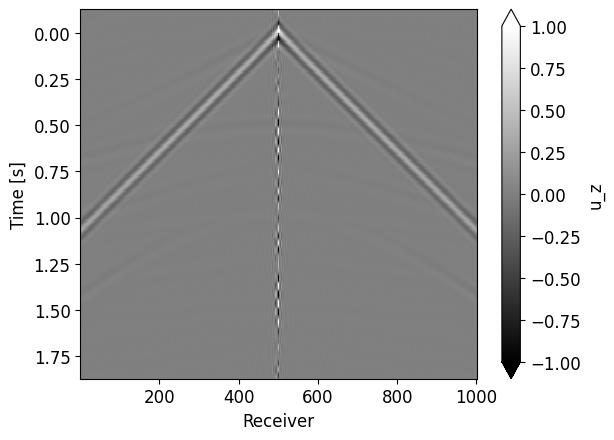

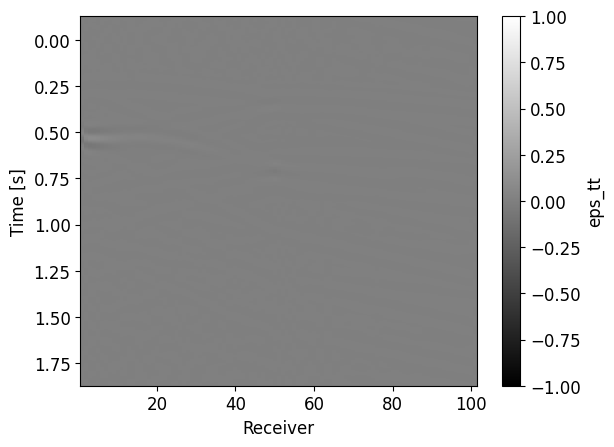

In [ ]:
# site = "local"

# # --- Connect to site ---
# if site == "local":
#     site = LocalSite(n_workers = 16)
# elif site == "stampede3":
#     site = Stampede3Site(rel_path = "FrequenSolve/ex_03/")
site = AWSSite(domain="localhost:5173")
site.sync(project)

# Create and submit frequency domain job
job = TimeDomainJob(
    name = "td_job",
    simulation = sim,
    f_min = 1.0,
    f_max = 20.0,
    T_max = 2.0
)

# if site.provisioned:
#     site.submit(job)
# else:
#     site.submit_SLURM(
#         job = job,
#         nodes = 1,
#         procs_per_node = 12,
#         procs_per_task = 1,
#         queue = "skx-dev",
#         duration = "00-00:01:00",
#     )

#     # Wait for SLURM job to complete
#     site.wait_completion(job)

simulation_id =site.submit(job, vcpu=4, memory=2048*4)
status = site.wait_for_completion(simulation_id)

if status == "FAILED":
    raise RuntimeError("Simulation failed")

trace_db = site.fetch_traces(job, upscale = 4)

wavelet = KlauderWavelet(
    f = [5, 15], 
    window = ("blackman", 0.25),
    center = 0.125
)
# wavelet.plot(f_max = 20.0)

print(trace_db)
for group in trace_db.groups:
    for shot in trace_db.shots(group):
        for comp in trace_db.components(group):
            td = trace_db.read_TD(group, comp, shot, wavelet, upscale = 4)
            plot = td.real.plot(
                vmin = -1, 
                vmax = 1, 
                y = "time", 
                yincrease = False,
                cmap = "gray"
            )
            plt.show()

In [ ]:
import pyvista as pv
from pathlib import Path
from frequensolve.util.mesh_convert import convert_gmp

sim = job.simulation
print(sim.mesh)
print(sim.mesh.file)
print(sim.mesh.format)

mesh_path = site.fetch_mesh(job)

# If it's GMP, convert to Gmsh first
if mesh_path.suffix.lower() == ".gmp":
    mesh_path = convert_gmp(mesh_path, mesh_path.with_suffix(".msh"), output_format="gmsh")

mesh = pv.read(str(mesh_path))
plotter = pv.Plotter()
plotter.add_mesh(mesh, show_edges=True, color="white")
plotter.show()